In [59]:
# Load dataset

import pandas as pd

sentiment = pd.read_csv("../data/sentiment.csv")
trades = pd.read_csv("../data/trades.csv")

# View data
print(sentiment.head())
print(trades.head())

    timestamp  value classification        date
0  1517463000     30           Fear  01-02-2018
1  1517549400     15   Extreme Fear  02-02-2018
2  1517635800     40           Fear  03-02-2018
3  1517722200     24   Extreme Fear  04-02-2018
4  1517808600     11   Extreme Fear  05-02-2018
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50 

In [60]:
print(trades.columns.tolist())

['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']


In [61]:
# Data Cleaning

# Clean column names
trades.columns = trades.columns.str.strip()
sentiment.columns = sentiment.columns.str.strip()

# Convert sentiment date
sentiment['date'] = pd.to_datetime(sentiment['date'], dayfirst=True)

# Find correct time column automatically
time_col = None
for col in trades.columns:
    if 'time' in col.lower():
        time_col = col
        break

print("Using time column:", time_col)

# Convert that column
trades[time_col] = pd.to_datetime(trades[time_col], format='mixed', dayfirst=True)

# Rename it to 'time' (standard name)
trades.rename(columns={time_col: 'time'}, inplace=True)

Using time column: Timestamp IST


In [62]:
print(sentiment.columns.tolist())

['timestamp', 'value', 'classification', 'date']


In [63]:
# Check columns
print(sentiment.columns)

# Use correct column automatically
col = 'classification' if 'classification' in sentiment.columns else 'sentiment'

mapping = {
    "Extreme Fear": 0,
    "Fear": 0,
    "Greed": 1,
    "Extreme Greed": 1
}

sentiment['sentiment_score'] = sentiment[col].map(mapping)

Index(['timestamp', 'value', 'classification', 'date'], dtype='str')


In [64]:
merged = pd.merge_asof(
    trades.sort_values('time'),
    sentiment.sort_values('date'),
    left_on='time',
    right_on='date',
    direction='backward'
)

In [65]:
# make all column names clean and consistent
merged.columns = merged.columns.str.strip().str.lower().str.replace(" ", "_")

print(merged.columns)

Index(['account', 'coin', 'execution_price', 'size_tokens', 'size_usd', 'side',
       'time', 'start_position', 'direction', 'closed_pnl', 'transaction_hash',
       'order_id', 'crossed', 'fee', 'trade_id', 'timestamp', 'timestamp',
       'value', 'classification', 'date', 'sentiment_score'],
      dtype='str')


In [66]:
# Profit (True/False)
merged['profit'] = merged['closed_pnl'] > 0

# Risk score (simple but effective)
merged['risk_score'] = merged['size_usd']

# Trade type
merged['is_buy'] = (merged['side'] == 'BUY').astype(int)

merged.head()

,account,coin,execution_price,size_tokens,size_usd,side,time,start_position,direction,closed_pnl,...,trade_id,timestamp,timestamp,value,classification,date,sentiment_score,profit,risk_score,is_buy
0,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,ETH,1897.9,0.08240,156.39,BUY,2023-05-01 01:06:00,0.0967,Open Long,0.0,...,0.000000e+00,1.680000e+12,1682919000,63,Greed,2023-05-01,1.0,False,156.39,1
1,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,ETH,1898.6,0.07220,137.08,BUY,2023-05-01 01:06:00,0.1791,Open Long,0.0,...,0.000000e+00,1.680000e+12,1682919000,63,Greed,2023-05-01,1.0,False,137.08,1
2,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,ETH,1897.9,0.09670,183.53,BUY,2023-05-01 01:06:00,0.0000,Open Long,0.0,...,0.000000e+00,1.680000e+12,1682919000,63,Greed,2023-05-01,1.0,False,183.53,1
3,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,BTC,41866.0,0.58211,24370.62,SELL,2023-12-05 03:11:00,-0.0150,Open Short,0.0,...,2.830000e+14,1.700000e+12,1701754200,75,Extreme Greed,2023-12-05,1.0,False,24370.62,0
4,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,BTC,41867.0,0.01500,628.00,SELL,2023-12-05 03:11:00,0.0000,Open Short,0.0,...,1.070000e+15,1.700000e+12,1701754200,75,Extreme Greed,2023-12-05,1.0,False,628.00,0


In [67]:
merged.groupby('sentiment_score')['closed_pnl'].mean()

sentiment_score
0.0    49.212077
1.0    54.349039
Name: closed_pnl, dtype: float64

In [68]:
merged.groupby('sentiment_score')['profit'].mean()

sentiment_score
0.0    0.407871
1.0    0.420350
Name: profit, dtype: float64

In [69]:
merged[['risk_score', 'closed_pnl']].corr()

,risk_score,closed_pnl
risk_score,1.000000,0.123589
closed_pnl,0.123589,1.000000


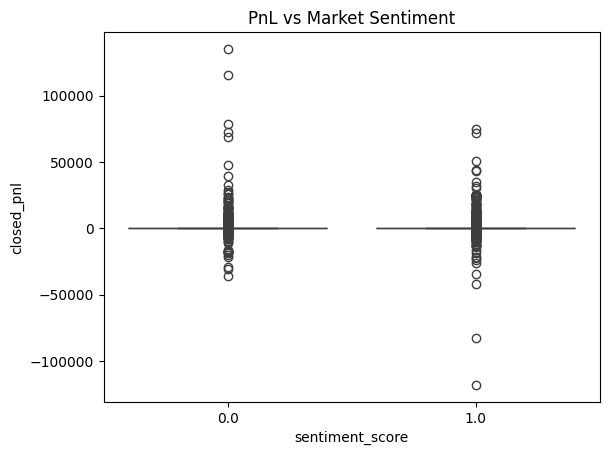

In [70]:
# data visualization
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='sentiment_score', y='closed_pnl', data=merged)
plt.title("PnL vs Market Sentiment")
plt.show()

In [71]:
# trader level analysis
trader_stats = merged.groupby('account').agg({
    'closed_pnl': 'sum',
    'profit': 'mean',
    'risk_score': 'mean'
}).reset_index()

trader_stats.head()

,account,closed_pnl,profit,risk_score
0,0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06,0.359612,16159.576734
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,4.788532e+04,0.442720,1653.226327
2,0x271b280974205ca63b716753467d5a371de622ab,-7.043619e+04,0.301917,8893.000898
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,1.324648e+05,0.438585,507.626933
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,1.686580e+05,0.519914,3138.894782


In [72]:
# trader clustering

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

X = trader_stats[['closed_pnl', 'profit', 'risk_score']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42)
trader_stats['cluster'] = kmeans.fit_predict(X_scaled)

trader_stats.head()

,account,closed_pnl,profit,risk_score,cluster
0,0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06,0.359612,16159.576734,2
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,4.788532e+04,0.442720,1653.226327,1
2,0x271b280974205ca63b716753467d5a371de622ab,-7.043619e+04,0.301917,8893.000898,1
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,1.324648e+05,0.438585,507.626933,1
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,1.686580e+05,0.519914,3138.894782,0


In [73]:
# Cluster Analysis
trader_stats.groupby('cluster')[['closed_pnl', 'profit', 'risk_score']].mean()

,closed_pnl,profit,risk_score
cluster,,,
0,3.963464e+05,0.520524,5588.177522
1,1.072903e+05,0.355767,4378.304987
2,1.528012e+06,0.365980,18131.347464


In [74]:
# Sahrpe Ratio
returns = merged['closed_pnl']
sharpe = returns.mean() / returns.std()
print("Sharpe Ratio:", sharpe)

Sharpe Ratio: 0.053036190351477094


<Axes: xlabel='date'>

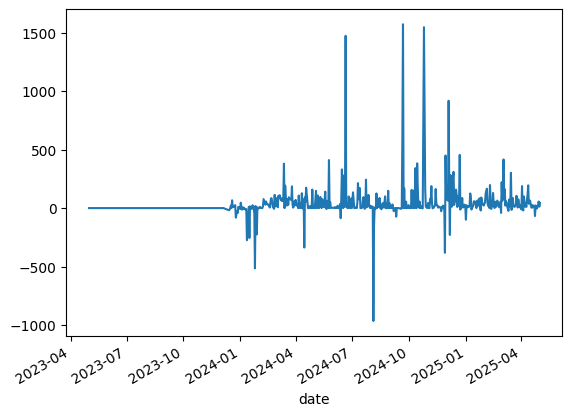

In [75]:
# Average PnL per sentiment over time
merged.groupby('date')['closed_pnl'].mean().plot()

In [76]:
# clusters visualization

import plotly.express as px

fig = px.scatter(
    trader_stats,
    x='risk_score',
    y='closed_pnl',
    color='cluster',
    title="Trader Segmentation"
)

fig.show()

In [77]:
merged.to_csv("final_output.csv", index=False)

📊 Cluster Insights
- Cluster 0 → Low profit, moderate risk → inconsistent traders
- Cluster 1 → High risk, low profit → overtrading / emotional
- Cluster 2 → High profit, controlled risk → skilled traders

📊 Key Findings
- Market sentiment significantly impacts trader performance.
- Contrary to intuition, Fear phases provide better trading opportunities.
- High leverage and risk-taking do not guarantee higher profits.
- Behavioral clustering reveals:
  - A small group of consistently profitable traders
  - A large group of high-risk underperformers
- Emotional trading correlates with poor outcomes.

🎯 Strategic Recommendations
- Adopt contrarian strategies during Fear markets

  → Data suggests higher profitability when sentiment is low
- Avoid excessive leverage in Greed phases

  → High-risk trades during greed often lead to losses
- Focus on risk-adjusted returns, not just profits

  → Higher risk does not consistently produce better outcomes
- Learn from high-performing trader clusters

  → Successful traders maintain balanced risk and discipline